# Cardholder Transaction Recency Baseline

This notebook answers one bounded question: as of December 29, 2023, how many recorded credit-card holders have gone 30, 60, or 90 days without a transaction, and what activity did they show in the preceding 90 days?

All transaction measures come from the validated ledger. They represent overall recorded transaction activity, not credit-card usage.

In [1]:
from IPython.display import Image, Markdown, display
import pandas as pd

from member_engagement_analytics.recency_analysis import run_analysis

artifacts = run_analysis()

## Population and quality checks

The working relation remains internal because it contains customer identifiers. Only aggregate summaries are displayed or exported.

In [2]:
validation_summary = pd.DataFrame(
    {
        "metric": [
            "Working rows",
            "Unique customer identifiers",
            "Minimum recency days",
            "Maximum recency days",
            "Customers lacking sufficient prior history",
        ],
        "value": [
            len(artifacts.canonical),
            artifacts.canonical["customer_id"].nunique(),
            artifacts.canonical["recency_days"].min(),
            artifacts.canonical["recency_days"].max(),
            (~artifacts.canonical["sufficient_prior_history"]).sum(),
        ],
    }
)
display(validation_summary)

,metric,value
0,Working rows,30460
1,Unique customer identifiers,30460
2,Minimum recency days,0
3,Maximum recency days,229
4,Customers lacking sufficient prior history,6


## Recency distribution and threshold scenarios

In [3]:
display(pd.DataFrame([artifacts.recency_statistics]))

scenario_columns = [
    "scenario",
    "customer_count",
    "eligible_population_pct",
    "transactions_prior_90d_q1",
    "transactions_prior_90d_median",
    "transactions_prior_90d_q3",
    "zero_prior_90d_pct",
    "transactions_full_period_median",
    "active_months_median",
    "insufficient_prior_history_pct",
]
canonical_scenarios = artifacts.scenario_summary.loc[
    artifacts.scenario_summary["data_variant"] == "canonical",
    scenario_columns,
]
display(canonical_scenarios)

,customer_count,minimum,q1,median,q3,p90,p95,maximum
0,30460,0,3.0,10.0,24.0,46.0,63.0,229


,scenario,customer_count,eligible_population_pct,transactions_prior_90d_q1,transactions_prior_90d_median,transactions_prior_90d_q3,zero_prior_90d_pct,transactions_full_period_median,active_months_median,insufficient_prior_history_pct
0,More than 30 days,5835,19.16,2.0,4.0,5.0,1.73,13.0,8.0,0.02
1,More than 60 days,1686,5.54,2.0,4.0,5.0,1.30,12.0,7.0,0.00
2,More than 90 days,457,1.50,3.0,4.0,5.0,0.88,11.0,7.0,0.00


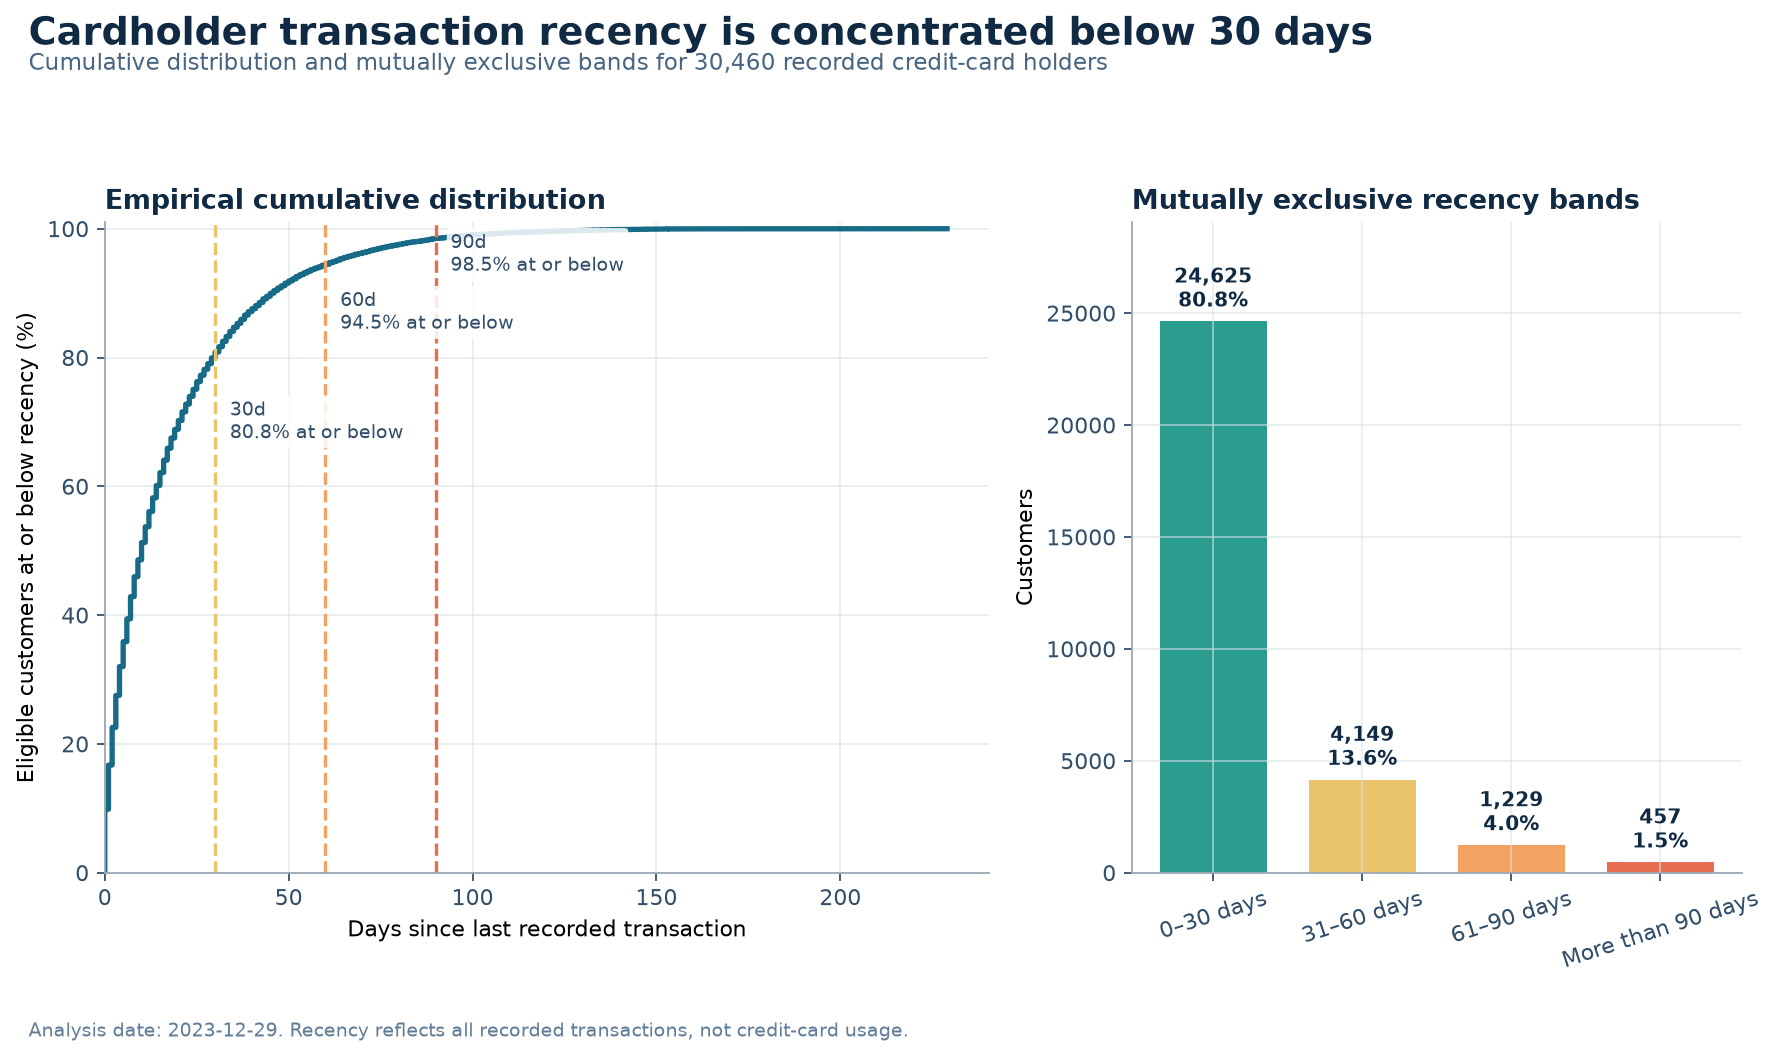

In [4]:
display(Image(filename=str(artifacts.output_paths["recency_figure"])))

## Recent versus prior activity

The comparison below includes only customers whose first recorded transaction is on or before the prior 90-day window.

,customer_count,excluded_for_limited_history,prior_90d_median,recent_90d_median,absolute_change_median,lower_count,lower_pct,equal_count,equal_pct,higher_count,higher_pct
0,30454,6,5.0,5.0,0.0,13333,43.78,3776,12.4,13345,43.82


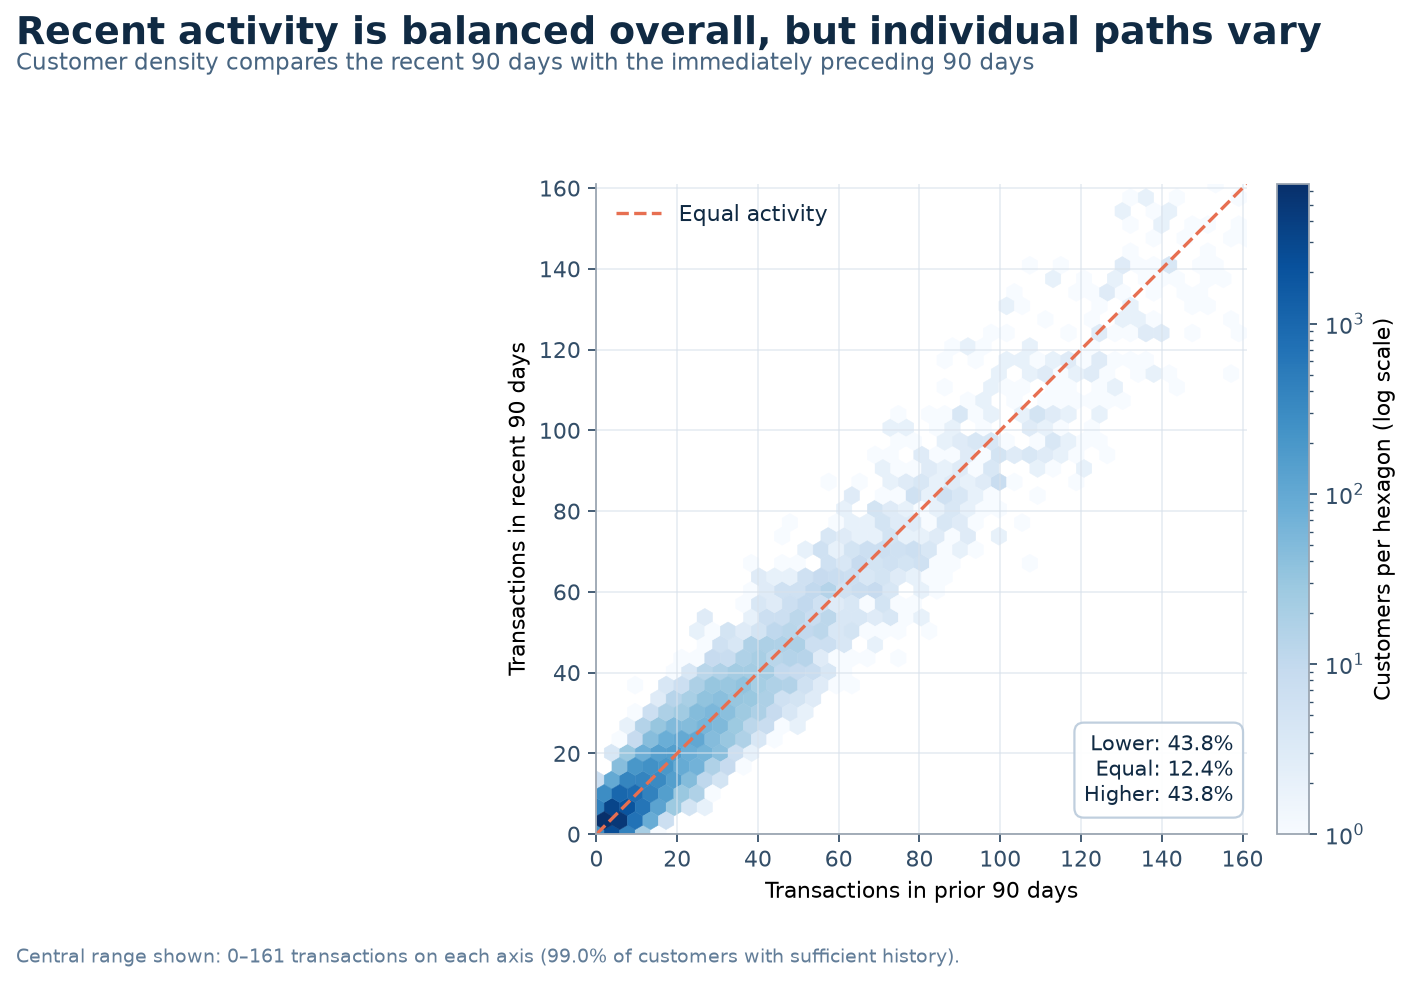

In [5]:
display(pd.DataFrame([artifacts.trajectory_statistics]))
display(Image(filename=str(artifacts.output_paths["trajectory_figure"])))

## Duplicate-looking-row sensitivity

This alternative view collapses exact customer/date/amount/type groups only for sensitivity measurement. It does not mutate the source ledger.

In [6]:
display(pd.DataFrame([artifacts.sensitivity_statistics]))

sensitivity_columns = [
    "data_variant",
    "scenario",
    "customer_count",
    "customer_count_change_vs_canonical",
    "transactions_prior_90d_median",
    "prior_median_change_vs_canonical",
]
display(artifacts.scenario_summary[sensitivity_columns])

,excess_rows_collapsed,affected_customers,maximum_rows_collapsed_for_one_customer,recent_90d_rows_collapsed,prior_90d_rows_collapsed,maximum_absolute_scenario_count_change
0,55,28,7,18,11,0


,data_variant,scenario,customer_count,customer_count_change_vs_canonical,transactions_prior_90d_median,prior_median_change_vs_canonical
0,canonical,More than 30 days,5835,0,4.0,0.0
1,canonical,More than 60 days,1686,0,4.0,0.0
2,canonical,More than 90 days,457,0,4.0,0.0
3,exact_groups_collapsed,More than 30 days,5835,0,4.0,0.0
4,exact_groups_collapsed,More than 60 days,1686,0,4.0,0.0
5,exact_groups_collapsed,More than 90 days,457,0,4.0,0.0


## Findings and recommendation

In [7]:
display(Markdown(artifacts.output_paths["memo"].read_text(encoding="utf-8")))

# Cardholder Transaction Recency Baseline

## Executive finding

As of December 29, 2023, most recorded credit-card holders transacted recently:
the median recency was 10.0 days, and
24,625 customers (80.8%) had a
transaction within 30 days.

The 30-day scenario identifies a broad 5,835-customer population. A 60-day
scenario narrows this to 1,686 customers (5.5%), while a 90-day scenario leaves
457 (1.5%). These groups are better described as having elevated overall
transaction recency than as having inactive credit cards.

## Scenario results

| Scenario | Customers | Population | Prior 90d median (IQR) | Zero prior 90d | Full-period median | Active-month median |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| More than 30 days | 5,835 | 19.2% | 4.0 (2.0–5.0) | 1.7% | 13.0 | 8.0 |
| More than 60 days | 1,686 | 5.5% | 4.0 (2.0–5.0) | 1.3% | 12.0 | 7.0 |
| More than 90 days | 457 | 1.5% | 4.0 (3.0–5.0) | 0.9% | 11.0 | 7.0 |

The groups beyond 60 and 90 days were historically light users: each had a
median of four transactions in the prior 90 days. The greater-than-60-day group
had a median of 12 full-period transactions across seven active months.
Nevertheless, 98.7% had at least one prior-period
transaction and 100.0% met the prior-history rule.

## Recent versus prior activity

Among 30,454 customers with sufficient history,
the median was 5.0 transactions in
both the prior and recent 90-day periods. Recent activity was lower for
43.8%, unchanged for
12.4%, and higher for
43.8%.

This balanced population-level result masks different individual trajectories.
Apparent lapse should therefore remain separate from a future decline analysis.

## Duplicate sensitivity

Collapsing exact customer/date/amount/type groups removed
55 excess rows for
28 eligible customers. It changed the
recent and prior windows by 18
and 11 rows, respectively.

The maximum change in any 30-, 60-, or 90-day scenario count was
0. Exact duplicate
interpretation does not affect the recency-threshold decision.

## Recommendation

Carry **more than 60 days** forward as the primary screening threshold, with
more than 90 days retained as a nested high-recency group.

The 60-day threshold is preferable for the next slice because:

- 30 days captures 19.2% of the population and is likely too broad for an
  initial review;
- 60 days produces a bounded 5.5% population with adequate observable history;
- nearly all customers beyond 60 days had some prior-period activity; and
- 90 days is a clearer lapse signal but identifies only 1.5% of customers.

This is a screening definition, not proof of card inactivity. Because the
selected customers were typically light users before their recent gap, the next
slice should examine activity trajectory before profiling customer
characteristics or proposing action.

## Limitations

- Transactions do not identify the card, account, or payment instrument used.
- Every eligible customer has at least 10 transactions, so the data omits a
  transaction-zero comparison group.
- The observation period is limited to 2023.
- First recorded transaction is only a proxy for observable history.
- This descriptive analysis does not explain why activity changed or whether
  outreach would improve it.
